In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

In [3]:

zip_file_path = '/content/drive/MyDrive/shakespere.zip'


extract_dir = '/content/extracted_data'
os.makedirs(extract_dir, exist_ok=True)


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File '{zip_file_path}' unzipped to '{extract_dir}' successfully!")
print(f"Contents of '{extract_dir}': {os.listdir(extract_dir)}")

File '/content/drive/MyDrive/shakespere.zip' unzipped to '/content/extracted_data' successfully!
Contents of '/content/extracted_data': ['shakespeare.txt']


## Q1: Implementing an RNN for Text Generation

### Task 1: Load a text dataset and preprocess it.

In [4]:
import tensorflow as tf
import numpy as np
import os


path_to_file = '/content/extracted_data/shakespeare.txt'


text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
print(f'Length of text: {len(text)} characters')


print(text[:250])
text = text.lower()
vocab = sorted(set(text))
print(f'Length of text after lowercasing: {len(text)} characters')
print(f'{len(vocab)} unique characters after lowercasing')

Length of text: 1115394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

Length of text after lowercasing: 1115394 characters
39 unique characters after lowercasing


### Task 2: Convert text into a sequence of characters (one-hot encoding or embeddings).

In [5]:
# Create a mapping from unique characters to indices
char_to_int = {char: i for i, char in enumerate(vocab)}
int_to_char = np.array(vocab)

text_as_int = np.array([char_to_int[char] for char in text])

print(f'Text has {len(text_as_int)} characters mapped to integers')
print(f'First 10 characters as integers: {text_as_int[:10]}')

# Create training examples and targets
seq_length = 100
examples_per_epoch = len(text) // (seq_length + 1)

# Create character datasets
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

for input_example, target_example in dataset.take(1):
    print('Input data:', repr(''.join(int_to_char[input_example.numpy()])))
    print('Target data:', repr(''.join(int_to_char[target_example.numpy()])))

# Batch size
BATCH_SIZE = 64

# Buffer size to shuffle the dataset
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
print(dataset)

Text has 1115394 characters mapped to integers
First 10 characters as integers: [18 21 30 31 32  1 15 21 32 21]
Input data: 'first citizen:\nbefore we proceed any further, hear me speak.\n\nall:\nspeak, speak.\n\nfirst citizen:\nyou'
Target data: 'irst citizen:\nbefore we proceed any further, hear me speak.\n\nall:\nspeak, speak.\n\nfirst citizen:\nyou '
<_BatchDataset element_spec=(TensorSpec(shape=(64, 100), dtype=tf.int64, name=None), TensorSpec(shape=(64, 100), dtype=tf.int64, name=None))>


###3. Define an RNN model using LSTM layers to predict the next character

In [6]:
import tensorflow as tf

tf.keras.backend.clear_session()

vocab_size = len(vocab)

# The embedding dimension
embedding_dim = 256

# Number of RNN units
rnn_units = 1024

def build_model(vocab_size, embedding_dim, rnn_units, batch_size, is_stateful=False):

    if is_stateful:
        input_layer = tf.keras.Input(batch_shape=[batch_size, None])
    else:
        input_layer = tf.keras.Input(shape=[None])

    # Connect the embedding layer
    embedding_output = tf.keras.layers.Embedding(vocab_size, embedding_dim)(input_layer)

    # Connect the LSTM layers
    lstm_output_1 = tf.keras.layers.LSTM(rnn_units,
                                         return_sequences=True,
                                         stateful=is_stateful,
                                         recurrent_initializer='glorot_uniform')(embedding_output)
    lstm_output_2 = tf.keras.layers.LSTM(rnn_units,
                                         return_sequences=True,
                                         stateful=is_stateful,
                                         recurrent_initializer='glorot_uniform')(lstm_output_1)

    # Connect the dense output layer
    output_layer = tf.keras.layers.Dense(vocab_size)(lstm_output_2)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    return model


model = build_model(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE,
    is_stateful=False)

model.summary()


for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")

sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices, axis=-1).numpy()

print(f"First 5 randomly sampled characters: {int_to_char[sampled_indices[:5]]}")

# Define the loss function
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

example_batch_loss = loss(target_example_batch, example_batch_predictions)
print(f"Prediction shape: {example_batch_predictions.shape}")
print(f"Scalar loss: {example_batch_loss.numpy()}")


model.compile(optimizer='adam', loss=loss)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 1024)     │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 1024)     │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 39)       │        39,975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,689,639 (52.22 MB)

 Trainable params: 13,689,639 (52.22 MB)

 Non-trainable params: 0 (0.00 B)

(64, 100, 39) # (batch_size, sequence_length, vocab_size)
First 5 randomly sampled characters: ['e' '\n' 'a' 'q' 'a']
Prediction shape: (64, 100, 39)
Scalar loss: 3.662202835083008


### Task 4: Train the model and generate new text by sampling characters one at a time.

In [8]:

checkpoint_dir = './training_checkpoints'

checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True)


model.compile(optimizer='adam', loss=loss)

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.LSTM):
        print(f"LSTM layer '{layer.name}' stateful property: {layer.stateful}")

EPOCHS = 30
history = model.fit(dataset, epochs=EPOCHS, callbacks=[checkpoint_callback])


import glob


inference_model = build_model(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=1,
    is_stateful=True)

# Restore the latest checkpoint
list_of_files = glob.glob(os.path.join(checkpoint_dir, 'ckpt_*.weights.h5'))
if list_of_files:

    latest_checkpoint_file = sorted(list_of_files, key=lambda x: int(os.path.basename(x).split('_')[1].split('.')[0]))[-1]
    inference_model.load_weights(latest_checkpoint_file)
    print(f"Loaded weights from: {latest_checkpoint_file}")
else:
    print("No checkpoint files found to load. Please ensure the training was successful and checkpoints were saved.")
    raise FileNotFoundError("No checkpoint files found in the specified directory.")

inference_model.build(tf.TensorShape([1, None]))
inference_model.summary()


def generate_text(model, start_string, num_generate=1000, temperature=1.0):
    # Evaluation step (generating text using the learned model)


    start_string_lower = start_string.lower() # Convert to lowercase
    input_eval = [char_to_int[s] for s in start_string_lower]
    input_eval = tf.expand_dims(input_eval, 0)


    text_generated = []

    # Reset the states of the RNN layers before starting to generate
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.LSTM) and layer.stateful:
            layer.reset_states()

    for i in range(num_generate):
        predictions = model(input_eval)

        predictions = tf.squeeze(predictions, 0)

        # Use a categorical distribution to sample the character returned by the model
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)

        text_generated.append(int_to_char[predicted_id])

    return (start_string + ''.join(text_generated))




LSTM layer 'lstm' stateful property: False
LSTM layer 'lstm_1' stateful property: False
Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 185ms/step - loss: 1.7256
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 36s 199ms/step - loss: 1.4554
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - loss: 1.3430
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 192ms/step - loss: 1.2708
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 191ms/step - loss: 1.2119
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 192ms/step - loss: 1.1553
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 190ms/step - loss: 1.0982
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 193ms/step - loss: 1.0364
Epoch 9/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 191ms/step - loss: 0.9681
Epoch 10/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 193ms/step - loss: 0.8954
Epoch 11/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 191ms/step - loss: 0.8165
Epoch 12/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 193ms/step - loss: 0.7341
Epoch 13/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 35s 192ms/step - loss: 0.649

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (1, None, 256)         │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (1, None, 1024)        │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (1, None, 1024)        │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, None, 39)          │        39,975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,689,639 (52.22 MB)

 Trainable params: 13,689,639 (52.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
print('--- Generated text (Temperature: 0.2) ---')
print(generate_text(inference_model, start_string="ROMEO:", temperature=0.2))

print('\n--- Generated text (Temperature: 0.8) ---')
print(generate_text(inference_model, start_string="ROMEO:", temperature=0.8))

print('\n--- Generated text (Temperature: 1.5) ---')
print(generate_text(inference_model, start_string="ROMEO:", temperature=1.5))

--- Generated text (Temperature: 0.2) ---
ROMEO:
the exchange of thy love's faithful vow for mine.

juliet:
i gave thee mine before thou didst unto the king
she's a changeling and none of your flesh and blood.

second keeper:
we do not suffer me this famous man,
since it is in my power.

first citizen:
for which my holy hope is it!

clown:
now, my lord; i'll follow you, and i'll swear it,
and stay at pomfret, then i see thee now,
deck'd in thy rights, as thou art starved with heaven,
for it requires the royal debt it lent you.

king edward iv:
but you will take exceptions to my boon.

lady grey:
not i, the county will be there before:
the crown so qualf? o hear me speak no more.

clifford:
no cause!
thy father came is come and very hold
on him, his sons, his father and my grandfather
to dry the time to come about his kingly glory,
to have him kill a king: poor trespasses,
more monstrous standing up, and vice shall be
to the slanderous of a maiment all, and given death
hath not a tomb s

## Q2: Sentiment Classification Using RNN

### Task 1: Load the IMDB sentiment dataset (tensorflow.keras.datasets.imdb).

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000, oov_token=2)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
print(f"Training entries: {len(train_data)}, labels: {len(train_labels)}")
print(f"Test entries: {len(test_data)}, labels: {len(test_labels)}")

# Display an example review and its label
print("Example training review (encoded):", train_data[0])
print("Example training label:", train_labels[0])

Training entries: 25000, labels: 25000
Test entries: 25000, labels: 25000
Example training review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16

### Task 2: Preprocess the text data by tokenization and padding sequences.

In [12]:
# A dictionary mapping words to an integer index
word_index = imdb.get_word_index()

# The first indices are reserved
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2  # Out of vocabulary
word_index["<UNUSED>"] = 3

reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])

# Decode and print an example review
print("Decoded example training review:", decode_review(train_data[0]))


maxlen = 256

train_data = tf.keras.preprocessing.sequence.pad_sequences(train_data,
                                                        value=word_index["<PAD>"],
                                                        padding='post',
                                                        maxlen=maxlen)

test_data = tf.keras.preprocessing.sequence.pad_sequences(test_data,
                                                       value=word_index["<PAD>"],
                                                       padding='post',
                                                       maxlen=maxlen)

print("Padded example training review:", train_data[0])
print("Length of padded example:", len(train_data[0]))
print("Decoded padded example training review:", decode_review(train_data[0]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Decoded example training review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profi

### Task 3: Train an LSTM-based model to classify reviews as positive or negative.

In [15]:
vocab_size = 10000
embedding_dim = 128

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

epochs = 10
history = model.fit(train_data,
                    train_labels,
                    epochs=epochs,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=1)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.5164 - loss: 0.6913 - val_accuracy: 0.5262 - val_loss: 0.6868
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.5494 - loss: 0.6760 - val_accuracy: 0.5689 - val_loss: 0.6579
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5890 - loss: 0.6383 - val_accuracy: 0.5711 - val_loss: 0.6441
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.6276 - loss: 0.7388 - val_accuracy: 0.5190 - val_loss: 0.7900
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.6033 - loss: 0.6388 - val_accuracy: 0.5936 - val_loss: 0.6220
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.6160 - loss: 0.5800 - val_accuracy: 0.5847 - val_loss: 0.6385
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.6101 - loss: 0.5990 - val_accuracy: 0.5887 - val_loss: 0.6303
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.6276 - loss: 0.5503 - val_accuracy: 0.5889 - v

### Task 4: Generate a confusion matrix and classification report.

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


predictions = (model.predict(test_data) > 0.5).astype("int32")

# Generate Confusion Matrix
cm = confusion_matrix(test_labels, predictions)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(test_labels, predictions, target_names=['Negative', 'Positive']))

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Confusion Matrix:
[[10927  1573]
 [ 2605  9895]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.87      0.84     12500
    Positive       0.86      0.79      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



### Task 5: Interpret why precision-recall tradeoff is important in sentiment classification

In sentiment classification, the **precision-recall tradeoff** is vital for understanding model performance, especially with imbalanced data or specific business goals.

*   **Precision**: Proportion of true positive predictions among all positive predictions (fewer false positives).
*   **Recall**: Proportion of true positive predictions among all actual positive instances (fewer false negatives).

**The Tradeoff:** There's an inverse relationship; improving one often degrades the other. For instance, being highly precise might miss some true positives, while high recall might increase false positives.

**Importance:** The optimal balance depends on the application:
*   **High Recall**: Crucial when missing actual positives is costly (e.g., detecting critical negative feedback).
*   **High Precision**: Important when false positives are costly (e.g., recommending positive reviews).

This tradeoff helps tailor the model's threshold to align with the specific goals and costs of false positives/negatives in sentiment analysis.

## Q3: Convolution Operations with Different Parameters

In [16]:
import numpy as np
import tensorflow as tf

# 1. Define the 5x5 input matrix
input_matrix = tf.constant([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=tf.float32)

input_reshaped = tf.reshape(input_matrix, [1, 5, 5, 1])

# 2. Define the 3x3 kernel
kernel = tf.constant([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
], dtype=tf.float32)

kernel_reshaped = tf.reshape(kernel, [3, 3, 1, 1])

print("Input Matrix (5x5):")
print(input_matrix.numpy())
print("\nKernel (3x3):")
print(kernel.numpy())

Input Matrix (5x5):
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

Kernel (3x3):
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


### Convolution Operations

In [17]:
import tensorflow as tf

# Stride = 1, Padding = 'VALID'
output_valid_s1 = tf.nn.conv2d(
    input=input_reshaped,
    filters=kernel_reshaped,
    strides=[1, 1, 1, 1], # [batch, height, width, channels]
    padding='VALID'
)

print("Output with Stride=1, Padding='VALID':")
print(tf.squeeze(output_valid_s1).numpy())

Output with Stride=1, Padding='VALID':
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [18]:
import tensorflow as tf

# Stride = 1, Padding = 'SAME'
output_same_s1 = tf.nn.conv2d(
    input=input_reshaped,
    filters=kernel_reshaped,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("Output with Stride=1, Padding='SAME':")
print(tf.squeeze(output_same_s1).numpy())

Output with Stride=1, Padding='SAME':
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]


In [19]:
import tensorflow as tf

# Stride = 2, Padding = 'VALID'
output_valid_s2 = tf.nn.conv2d(
    input=input_reshaped,
    filters=kernel_reshaped,
    strides=[1, 2, 2, 1],
    padding='VALID'
)

print("Output with Stride=2, Padding='VALID':")
print(tf.squeeze(output_valid_s2).numpy())

Output with Stride=2, Padding='VALID':
[[0. 0.]
 [0. 0.]]


In [20]:
import tensorflow as tf

# Stride = 2, Padding = 'SAME'
output_same_s2 = tf.nn.conv2d(
    input=input_reshaped,
    filters=kernel_reshaped,
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("Output with Stride=2, Padding='SAME':")
print(tf.squeeze(output_same_s2).numpy())

Output with Stride=2, Padding='SAME':
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


## Q4: CNN Feature Extraction with Filters and Pooling

### Task 1: Implement Edge Detection Using Convolution

In [21]:
from tensorflow.keras.utils import get_file

image_url = 'https://tensorflow.org/images/tf_logo_social.png'
new_image_path = get_file('tf_logo.png', image_url)

print(f"Downloaded new image to: {new_image_path}")

17046/17046 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Downloaded new image to: /root/.keras/datasets/tf_logo.png


### Task 1: Implementing Edge Detection Using Convolution (with new image)

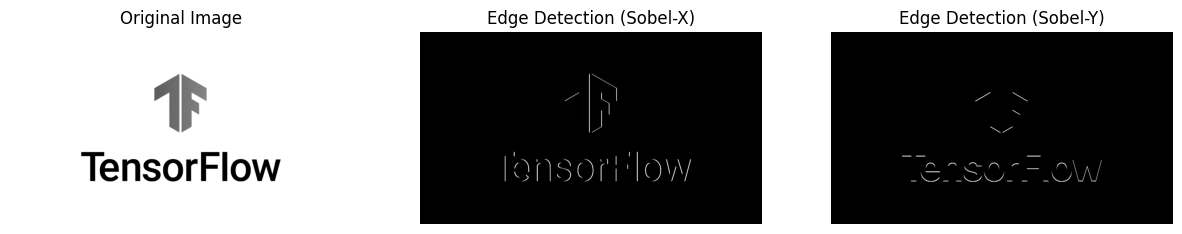

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = new_image_path
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    raise FileNotFoundError(f"Error: Image not found at {image_path}. Please check the path and ensure the image is accessible.")

# Define Sobel X and Y filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)


filtered_x = cv2.filter2D(original_image, -1, sobel_x)

# Apply Sobel Y filter
filtered_y = cv2.filter2D(original_image, -1, sobel_y)

# Display images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_x, cmap='gray')
plt.title('Edge Detection (Sobel-X)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_y, cmap='gray')
plt.title('Edge Detection (Sobel-Y)')
plt.axis('off')

plt.show()

### Task 2: Implement Max Pooling and Average Pooling

In [23]:
import tensorflow as tf
import numpy as np


original_matrix = tf.constant(np.random.rand(4, 4) * 10, dtype=tf.float32)
input_for_pooling = tf.reshape(original_matrix, [1, 4, 4, 1])


max_pooled_output = tf.nn.max_pool(
    input=input_for_pooling,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='VALID'
)


avg_pooled_output = tf.nn.avg_pool(
    input=input_for_pooling,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='VALID'
)

# Print the results
print("Original 4x4 Matrix:")
print(original_matrix.numpy().round(2))

print("\nMax-Pooled Matrix (2x2, Stride 2):")
print(tf.squeeze(max_pooled_output).numpy().round(2))

print("\nAverage-Pooled Matrix (2x2, Stride 2):")
print(tf.squeeze(avg_pooled_output).numpy().round(2))

Original 4x4 Matrix:
[[7.82 7.12 2.04 7.07]
 [9.17 5.38 5.28 0.65]
 [3.86 6.81 2.26 1.44]
 [2.18 6.48 6.42 3.15]]

Max-Pooled Matrix (2x2, Stride 2):
[[9.17 7.07]
 [6.81 6.42]]

Average-Pooled Matrix (2x2, Stride 2):
[[7.37 3.76]
 [4.83 3.32]]


## Q5: Implementing and Comparing CNN Architectures

### Task 1: Implement AlexNet Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the AlexNet model
def build_alexnet(input_shape=(227, 227, 3), num_classes=10):
    model = models.Sequential([
        # First Conv Layer
        layers.Conv2D(96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # Second Conv Layer
        layers.Conv2D(256, kernel_size=(5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # Third Conv Layer
        layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),

        # Fourth Conv Layer
        layers.Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),

        # Fifth Conv Layer
        layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Build and print summary of AlexNet
alexnet_model = build_alexnet()
print("AlexNet Model Summary:")
alexnet_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AlexNet Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,322,314 (222.48 MB)

 Trainable params: 58,322,314 (222.48 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2: Implement a Residual Block and ResNet

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def residual_block(input_tensor, filters):
    x = layers.Conv2D(filters, kernel_size=(3, 3), padding='same', activation='relu')(input_tensor)
    x = layers.Conv2D(filters, kernel_size=(3, 3), padding='same')(x)

    if input_tensor.shape[-1] != filters:
        input_tensor = layers.Conv2D(filters, kernel_size=(1, 1), padding='same')(input_tensor)

    output = layers.add([x, input_tensor])
    output = layers.ReLU()(output)
    return output

# Create a ResNet-like model
def build_resnet_like(input_shape=(224, 224, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Initial Conv2D layer
    x = layers.Conv2D(64, kernel_size=(7, 7), strides=(2, 2), padding='same', activation='relu')(inputs)

    # Apply two residual blocks
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Build and print summary of ResNet-like model
resnet_model = build_resnet_like()
print("\nResNet-like Model Summary:")
resnet_model.summary()


ResNet-like Model Summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ conv2d_2[0][0],   │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 112, 112,  │          0 │ conv2d_4[0][0],   │
│                     │ 64)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │      1,290 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 166,794 (651.54 KB)

 Trainable params: 166,794 (651.54 KB)

 Non-trainable params: 0 (0.00 B)